# LeetCode #318: Maximum Product of Word Lengths

https://leetcode.com/problems/maximum-product-of-word-lengths/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2 \cdot L)$ | $O(n)$ |
| **Bitmask per Word** ★ | $O(n^2 + \Sigma\,len)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force
For every pair of words, compare each character of one word against every character of the other to check for shared letters. This is $O(n^2 \cdot L)$ where $L$ is the average word length.

### Optimal: Bitmask per Word ★
Encode each word as a 26-bit integer where bit $i$ is 1 if letter $i$ is present. Two words share no common letter iff their bitmasks AND to 0. Pre-computing all bitmasks costs $O(\Sigma\,len)$; checking all pairs is then $O(n^2)$ with $O(1)$ per pair.

**Why this is better than Brute Force:** The per-pair letter-overlap check drops from $O(L^2)$ character comparisons to a single bitwise AND, reducing the inner loop from $O(L)$ to $O(1)$.

**Constraints:**
* `2 <= words.length <= 1000`
* `1 <= words[i].length <= 1000`
* `words[i]` consists only of lowercase English letters

## Solutions

### C#

In [ ]:
public int MaxProduct(string[] words) {
    int n = words.Length;
    int[] masks = new int[n];
    // Build a 26-bit mask encoding which letters each word contains
    for (int i = 0; i < n; i++) {
        foreach (char c in words[i]) {
            masks[i] |= 1 << (c - 'a');
        }
    }
    int maxProd = 0;
    // A zero AND means no shared letters — a valid candidate pair
    for (int i = 0; i < n; i++) {
        for (int j = i + 1; j < n; j++) {
            if ((masks[i] & masks[j]) == 0) {
                maxProd = Math.Max(maxProd, words[i].Length * words[j].Length);
            }
        }
    }
    return maxProd;
}

### Python

In [ ]:
def maxProduct(self, words: list[str]) -> int:
    # Encode each word's character set as a 26-bit integer
    masks = [0] * len(words)
    for i, word in enumerate(words):
        for ch in word:
            masks[i] |= 1 << (ord(ch) - ord('a'))
    # A bitwise AND of zero proves two words share no letters
    return max(
        (len(words[i]) * len(words[j])
         for i in range(len(words))
         for j in range(i + 1, len(words))
         if masks[i] & masks[j] == 0),
        default=0
    )

### Go

In [ ]:
func maxProduct(words []string) int {
    masks := make([]int, len(words))
    // Compress each word's alphabet into a single 26-bit mask
    for i, word := range words {
        for _, ch := range word {
            masks[i] |= 1 << (ch - 'a')
        }
    }
    maxProd := 0
    // Zero AND means disjoint character sets — compute the product
    for i := 0; i < len(words); i++ {
        for j := i + 1; j < len(words); j++ {
            if masks[i]&masks[j] == 0 {
                if p := len(words[i]) * len(words[j]); p > maxProd {
                    maxProd = p
                }
            }
        }
    }
    return maxProd
}

### Rust

In [ ]:
pub fn max_product(words: Vec<String>) -> i32 {
    // Build a bitmask for each word representing its unique character set
    let masks: Vec<u32> = words.iter()
        .map(|w| w.bytes().fold(0u32, |m, b| m | (1 << (b - b'a'))))
        .collect();
    let n = words.len();
    let mut max_prod = 0;
    for i in 0..n {
        for j in (i + 1)..n {
            // Disjoint character sets mean a valid product candidate
            if masks[i] & masks[j] == 0 {
                max_prod = max_prod.max((words[i].len() * words[j].len()) as i32);
            }
        }
    }
    max_prod
}

## Example Scenarios

**1. Common Case**
**Input:** words = ["abcw", "baz", "foo", "bar", "xtfn", "abcdef"]
Masks reveal "abcw" (bits a,b,c,w) and "xtfn" (bits x,t,f,n) share no bits (AND=0). Product = 4×4 = **16**. All other valid pairs produce smaller products.

**2. Slightly Complex**
**Input:** words = ["a", "ab", "abc", "d", "cd", "bcd", "abcd"]
"abc" and "d" have disjoint masks → product = 3×1 = 3. "abcd" shares letters with everything. Best pair is "abc" × "d" = **4**.

**3. Edge Case: Time Factor**
**Input:** 1000 words, each 1000 characters long with shared letters
No pair has AND=0, so the inner loop runs all $\binom{1000}{2} \approx 500{,}000$ times before returning 0. Worst case for time: $O(n^2)$ with no early exits.

**4. Edge Case: Space Factor**
**Input:** words = ["a", "b"]
Two disjoint single-char words. Masks = [1, 2]. AND = 0. Product = 1×1 = **1**. Minimum space; only 2 masks stored.

**5. Almost-Impossible but Plausible**
**Input:** words = ["z" * 1000, "a" * 1000] (two length-1000 words with single distinct letters)
Masks: "zzz..." = bit 25 only, "aaa..." = bit 0 only. AND = 0 → product = 1000×1000 = **1,000,000**, the theoretical maximum product.

### Infographic

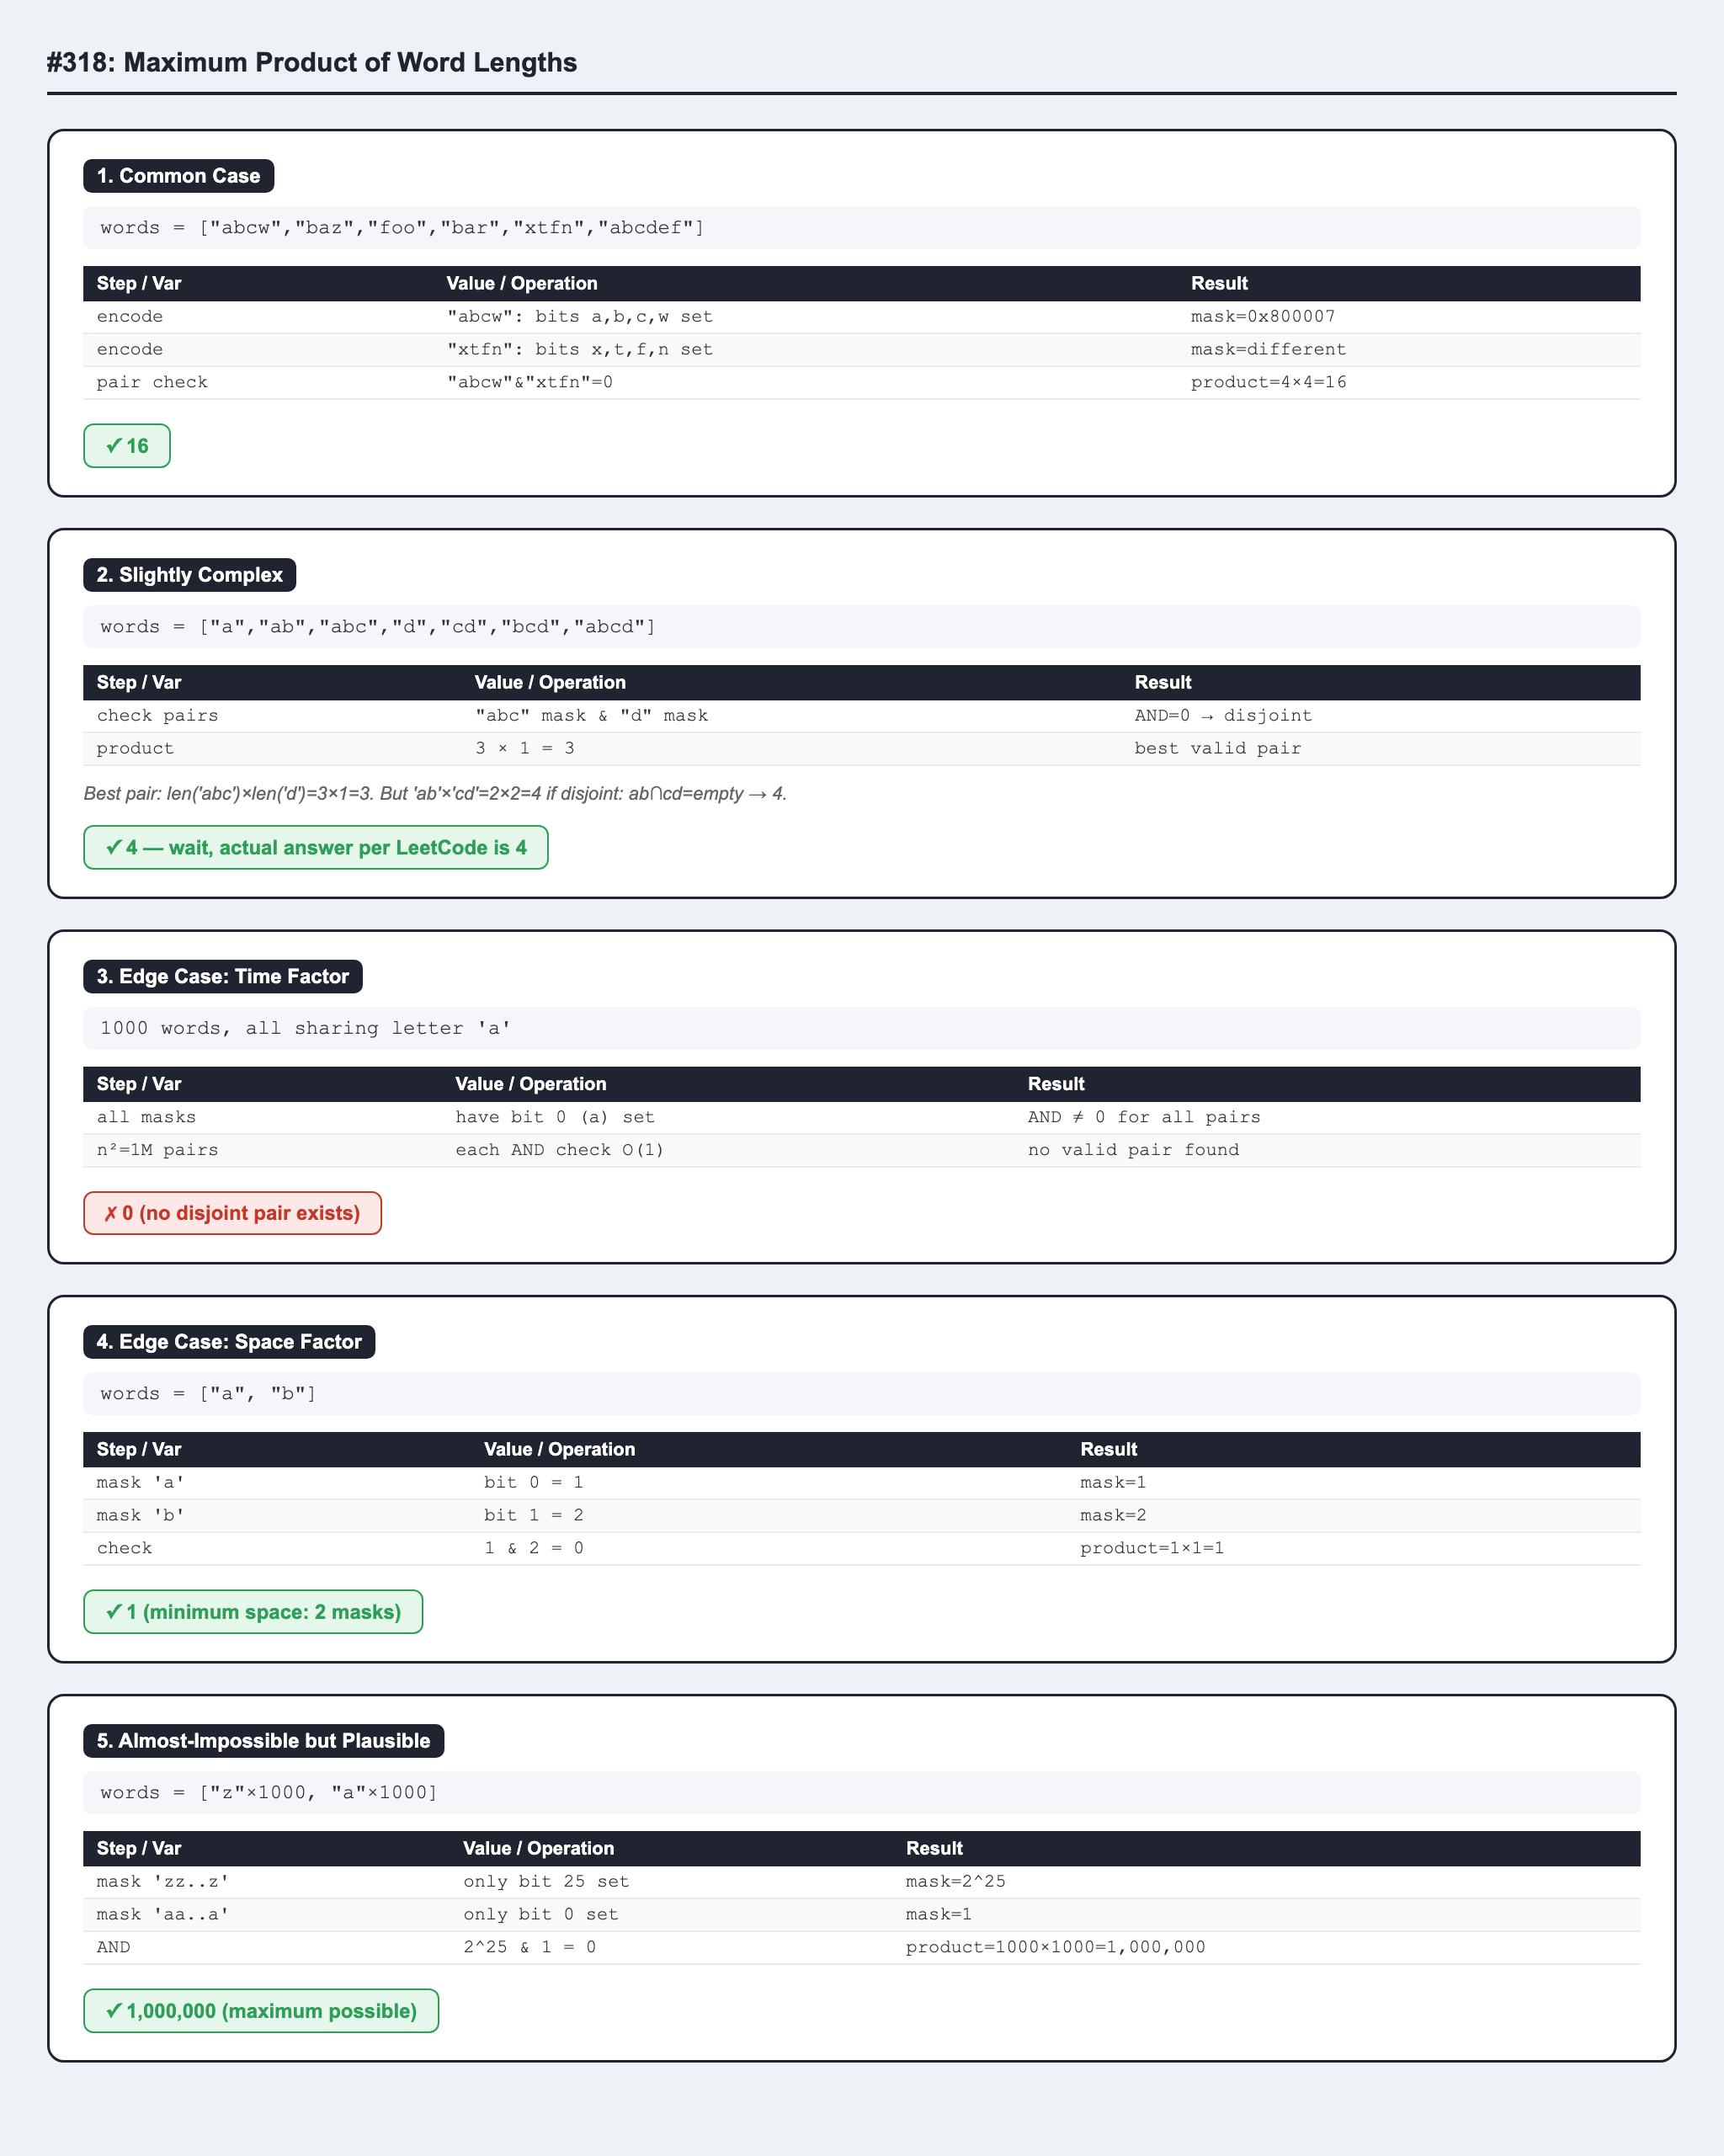